#### UAV Autonomy Summer Camp 2026: Abto Software

---

# <center> Домашнє завдання №2 <center>

#### виконав Горбатюк Данило

<br>

> Маючи вхідне зображення гри, намальованої на папері, необхідно його проаналізувати та визначити стан ігрового поля. Створіть власне зображення гри (радимо скористатися чорним маркером), використавши іншу комбінацію хрестиків та нуликів, ніж у прикладі.

> Необхідно: <br>
    1. Реалізувати розпізнавання сітки ігрового поля, а також усіх клітинок сітки та символів у них.<br>
    2. Відобразити результати розпізнавання на вихідному зображенні (виділити сітку та символи).<br>
    3. Якщо на полі є виграшна комбінація (три однакові символи поспіль по горизонталі, вертикалі або діагоналі), провести через неї пряму лінію.

<br>

Було взято власне зображення (4 комбінації: ніхто не виграв, виграли нулики, виграли хрестики, і дуже погані контури: незамкнені, криві фігури, зазори) і розбито на 4 окремі зображення.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

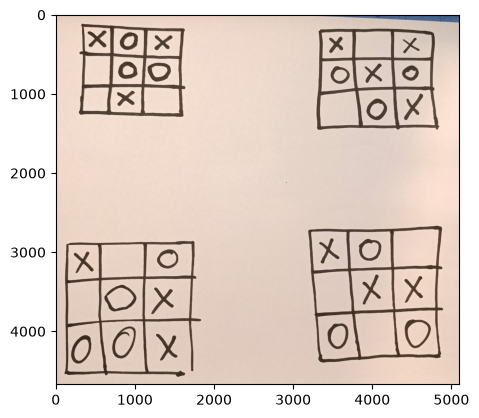

In [3]:
full_field_90 = cv2.imread("input/full_field_90.jpg")
plt.imshow(full_field_90)
plt.show()

<i> Зображення ігрових полів на одному аркуші, фото зроблено перпендикулярно до аркуша паперу </i>

In [4]:
def plot_images_in_row(images, titles=None, figsize=(15, 5)):
    number_images = len(images)
    fig, axes = plt.subplots(1, number_images, figsize=figsize)
    if number_images == 1:
        axes = [axes]
    for i in range(number_images):
        axes[i].imshow(images[i])
        if titles is not None and i < len(titles):
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.rcParams.update(plt.rcParamsDefault)
    plt.tight_layout()
    plt.show()

In [5]:
bad_photo_and_circles_wins = cv2.imread("input/cases/bad_photo_and_circles_wins.jpg", cv2.IMREAD_COLOR_RGB)
crosses_wins = cv2.imread("input/cases/crosses_wins.jpg", cv2.IMREAD_COLOR_RGB)
nobody_wins = cv2.imread("input/cases/nobody_wins.jpg", cv2.IMREAD_COLOR_RGB)
nobody_wins_2 = cv2.imread("input/cases/nobody_wins_2.jpg", cv2.IMREAD_COLOR_RGB)

In [6]:
images = {
    "bad photo & circles wins": bad_photo_and_circles_wins,
    "crosses wins": crosses_wins,
    "nobody wins": nobody_wins,
    "nobody wins 2": nobody_wins_2,
}

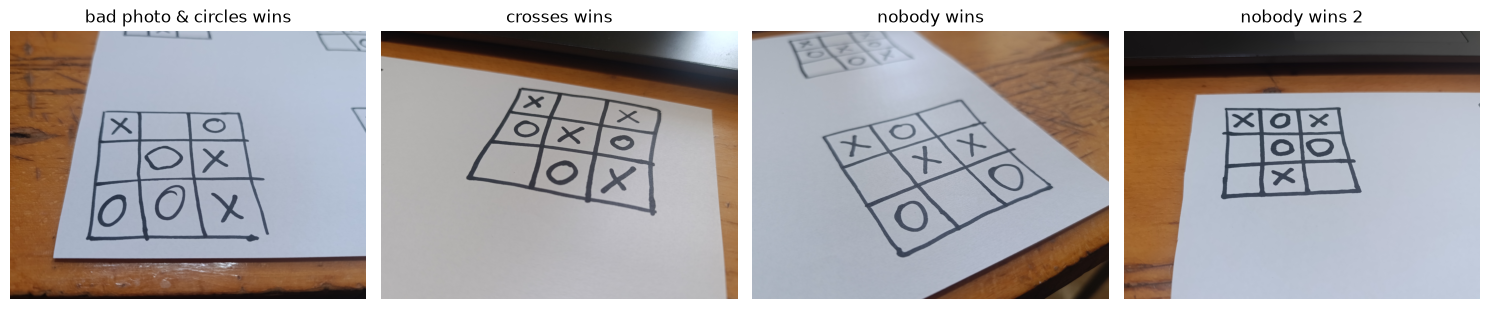

In [7]:
plot_images_in_row(
    list(images.values()),
    list(images.keys()),
)

## Попередня обробка зображення

Використаємо Отсу, щоб знайти маски паперу на якому зображена сітка


In [8]:
image_and_masks = {}

for name, image in images.items():
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7,7), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((21, 21), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    image_and_masks.update({name: mask})
    # result = cv2.bitwise_and(image, image, mask=mask)


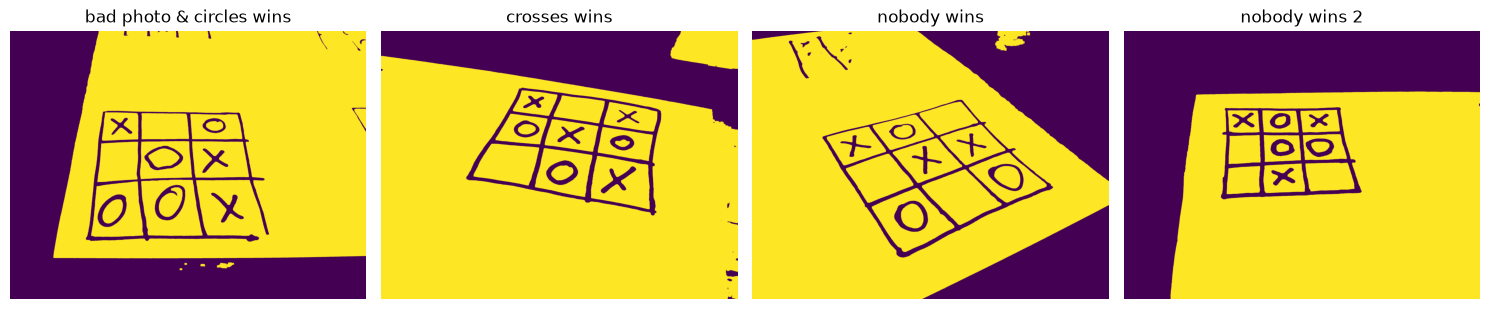

In [9]:
plot_images_in_row(
    list(image_and_masks.values()),
    list(image_and_masks.keys())
)

In [10]:
print(set(image_and_masks["nobody wins"].flatten()))
# 0 - фон, 255 - аркуш

{np.uint8(0), np.uint8(255)}


In [11]:
img_edges = {}
img_contours = {}

for name, mask in image_and_masks.items():
    edged = cv2.Canny(mask, 100, 200)
    cv2.waitKey(0)
    contours, hierarchy = cv2.findContours(edged,
                      cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    print(f"num of contours founded \"{name}\": {str(len(contours))}")
    img_edges.update({name: edged})
    img_contours.update({name: contours})

num of contours founded "bad photo & circles wins": 27
num of contours founded "crosses wins": 22
num of contours founded "nobody wins": 22
num of contours founded "nobody wins 2": 3


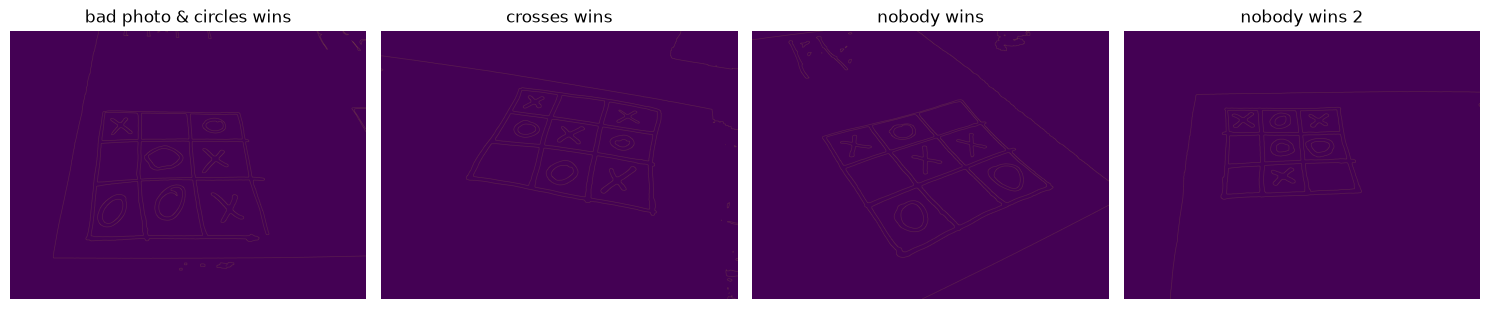

In [12]:
plot_images_in_row(
    list(img_edges.values()),
    list(img_edges.keys())
)

bad photo & circles wins: convex = False, area = 2229592.5


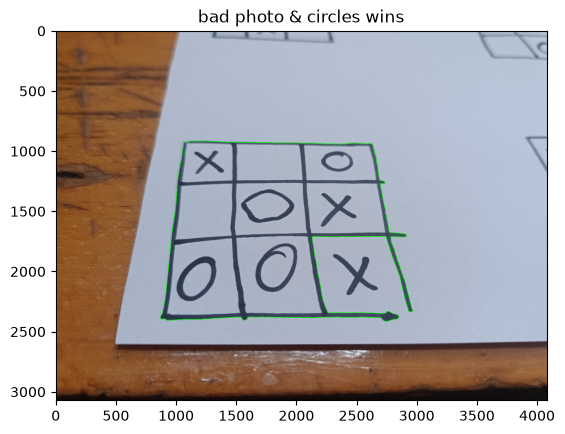

crosses wins: convex = False, area = 2189528.0


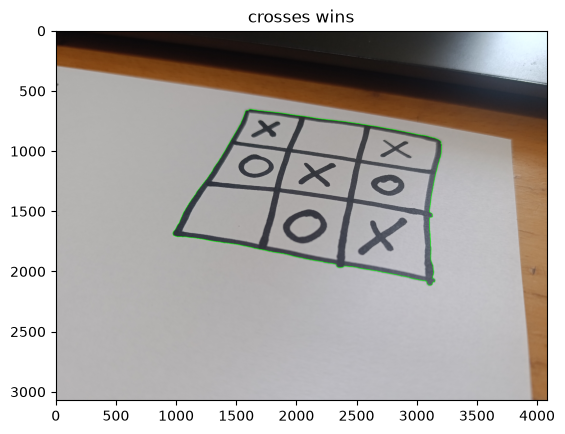

nobody wins: convex = False, area = 2563531.0


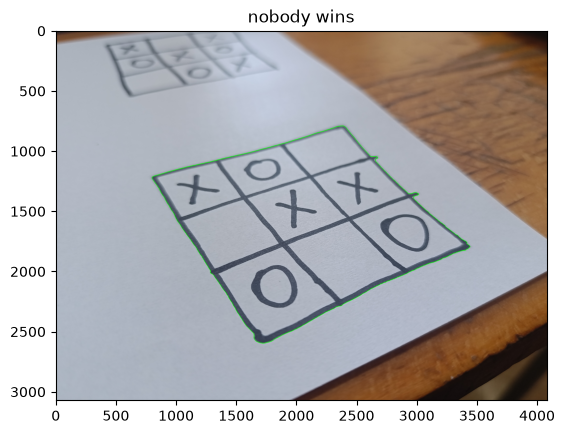

nobody wins 2: convex = False, area = 1431789.0


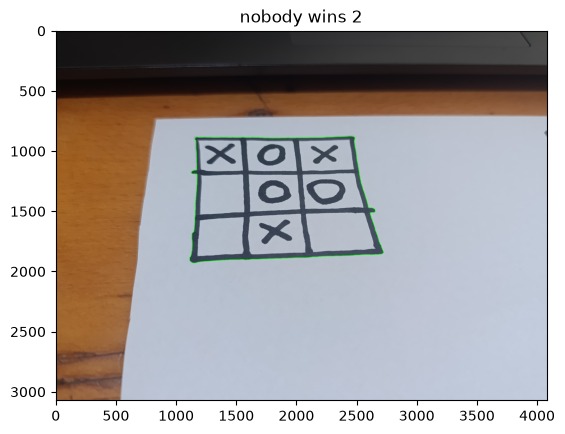

In [13]:
for name, contours in img_contours.items():
    largest = max(contours, key=cv2.contourArea)
    canvas = cv2.drawContours(images[name].copy(), [largest], -1, (0, 255, 0), 3)
    is_convex = cv2.isContourConvex(largest)
    print(f"{name}: convex = {is_convex}, area = {cv2.contourArea(largest)}")
    plt.imshow(canvas)
    plt.title(name)
    plt.show()

<i>зображення "bad photo & circles wins" має розрив <br>
     тому робити перспективу будемо після апроксимації фігури у довільний прямокутник

In [14]:
canvases = {}
approx_field_contours = {}

for name, contours in img_contours.items():
    largest = max(contours, key=cv2.contourArea)
    peri = cv2.arcLength(largest, True)
    box = cv2.approxPolyDP(largest, peri * 0.07, True)
    canvas = cv2.drawContours(images[name].copy(), [box], -1, (0, 255, 0), 3)
    canvases.update({name: canvas})
    approx_field_contours.update({name: box.tolist()})

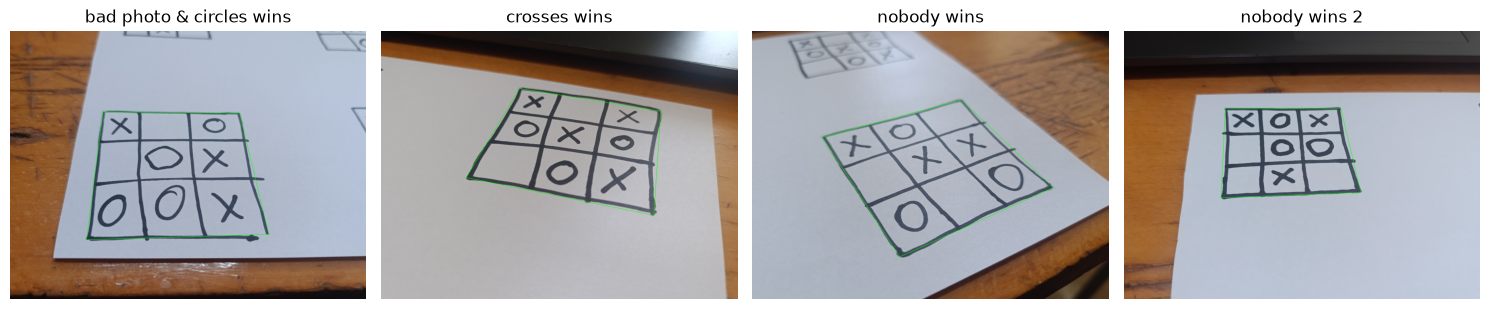

In [15]:
plot_images_in_row(
    list(canvases.values()),
    list(canvases.keys()),
)

In [16]:
[f"{name}: box = {box}" for name, box in approx_field_contours.items()]

['bad photo & circles wins: box = [[[1066, 928]], [[875, 2393]], [[2964, 2331]], [[2629, 942]]]',
 'crosses wins: box = [[[973, 1681]], [[3121, 2113]], [[3201, 921]], [[1584, 661]]]',
 'nobody wins: box = [[[2394, 791]], [[800, 1219]], [[1686, 2589]], [[3443, 1795]]]',
 'nobody wins 2: box = [[[2484, 886]], [[1162, 887]], [[1115, 1912]], [[2716, 1851]]]']

In [27]:
def order_points(box: list):
    box = np.array(box, dtype="float32").reshape(-1, 2)

    cx, cy = box.mean(axis=0)
    angles = np.arctan2(box[:, 1] - cy, box[:, 0] - cx)
    ordered = box[np.argsort(angles)]

    start = np.argmin(ordered.sum(axis=1))
    ordered = np.roll(ordered, -start, axis=0)

    top_left = ordered[0].tolist()
    top_right = ordered[1].tolist()
    bottom_right = ordered[2].tolist()
    bottom_left = ordered[3].tolist()

    return top_left, top_right, bottom_right, bottom_left

In [30]:
for name, box in approx_field_contours.items():
    approx_field_contours[name] = order_points(box)
    print(f"approx_field_contours[{name}]: {approx_field_contours[name]}")

approx_field_contours[bad photo & circles wins]: ([1066.0, 928.0], [2629.0, 942.0], [2964.0, 2331.0], [875.0, 2393.0])
approx_field_contours[crosses wins]: ([1584.0, 661.0], [3201.0, 921.0], [3121.0, 2113.0], [973.0, 1681.0])
approx_field_contours[nobody wins]: ([800.0, 1219.0], [2394.0, 791.0], [3443.0, 1795.0], [1686.0, 2589.0])
approx_field_contours[nobody wins 2]: ([1162.0, 887.0], [2484.0, 886.0], [2716.0, 1851.0], [1115.0, 1912.0])


In [36]:
warped_img = {}

for name, box in approx_field_contours.items():
    src_pts = np.array(box, dtype="float32").reshape(4, 2)
    width = 600
    height = 600
    dst_pts = np.float32([[0, 0],
                          [width, 0],
                          [width, height],
                          [0, height]])
    matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(images[name], matrix, (width, height))
    warped_img.update({name: warped})

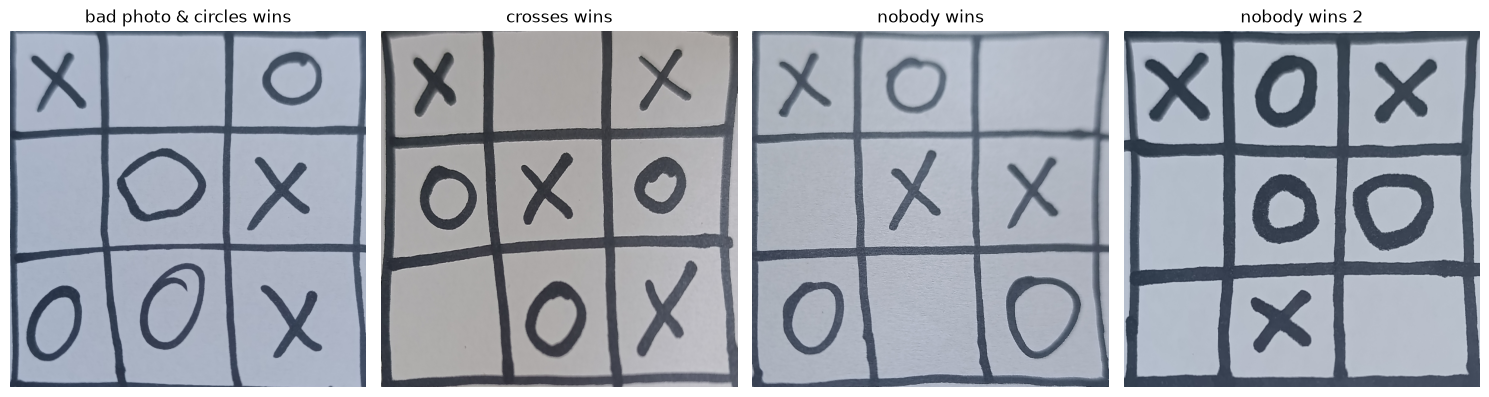

In [37]:
plot_images_in_row(
    list(warped_img.values()),
    list(warped_img.keys()),
)

In [ ]:
# TODO:
#  1. Дослідити як працює метод Хафа (детекція ліній)
#  2. Відібрати найбільші
#  3. Поділити сітку на сектори --->>> для лінії у разі виграшної комбінації, зберегти центри секторів
#  4. Додати маску навколо кожного сектору, або додати margin
#  5. Перевести у бінарне зображення
#  6. Canny Edge Detection для обʼєкта всередині: X / O / empty
#  7. Записати для кожного зображення: назва, матриця стану поля